<a href="https://colab.research.google.com/github/varun0852/for-study/blob/master/HandsOn_with_Sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
data = load_iris()
features = data['data']
feature_names = data['feature_names']
label = data['target']
label_names = data['target_names']

In [ ]:
dic = {}
for i in feature_names:
    dic[i] = 0
dic["label"] = 0

sepal_length = []
sepal_width = []
petal_length = []
petal_width = []


for i in range(len(features)):
    for j in range(len(features[i])):
        if j == 0:
            sepal_length.append(features[i][j])
        elif j == 1:
            sepal_width.append(features[i][j])
        elif j == 2:
            petal_length.append(features[i][j])
        else:
            petal_width.append(features[i][j])

label = label.tolist()


dic["sepal length (cm)"] = sepal_length
dic["sepal width (cm)"] = sepal_width
dic["petal length (cm)"] = petal_length
dic["petal width (cm)"] = petal_width
dic["label"] = label

In [ ]:
label

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2]

In [ ]:
df = pd.DataFrame(dic)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   label              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


<Axes: >

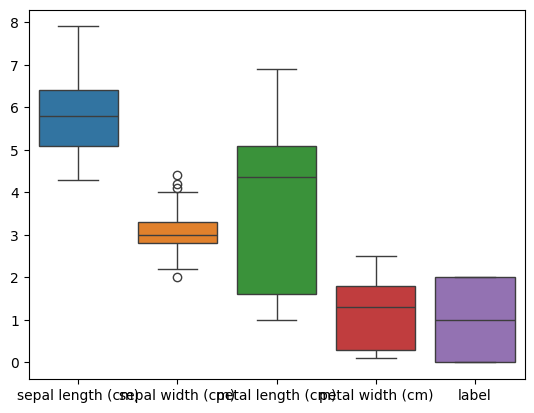

In [ ]:
sns.boxplot(df)

In [ ]:
q1 = np.quantile(df["sepal width (cm)"], 0.25)
q3 = np.quantile(df["sepal width (cm)"], 0.75)
iqr = q3-q1
lb = q1 - 1.5*iqr
ub = q3 + 1.5*iqr
df1 = df[(df['sepal width (cm)'] > lb) & (df['sepal width (cm)'] < ub)]

<Axes: >

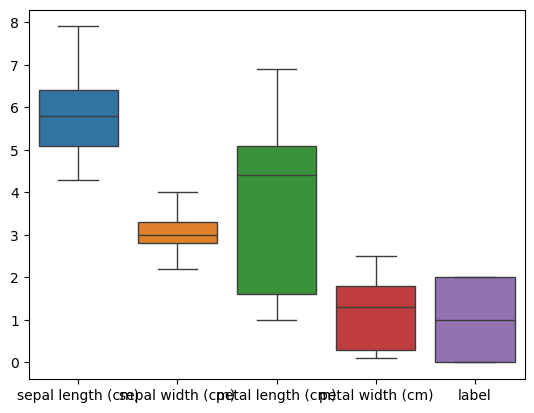

In [ ]:
sns.boxplot(df1)

C:\Users\Dev\AppData\Local\Temp\ipykernel_28784\2128019508.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["sepal length (cm)"])


<Axes: xlabel='sepal length (cm)', ylabel='Density'>

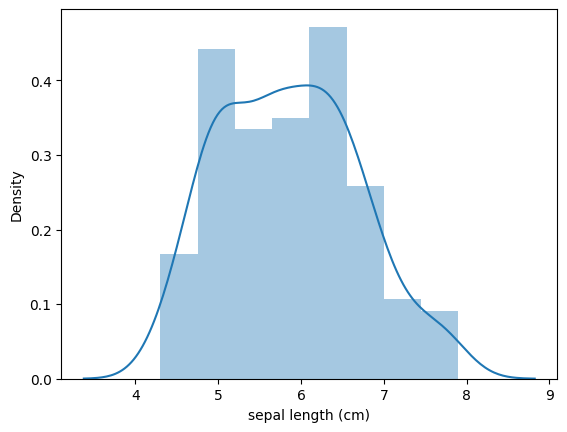

In [ ]:
sns.distplot(df1["sepal length (cm)"])

C:\Users\Dev\AppData\Local\Temp\ipykernel_28784\689090166.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["sepal width (cm)"])


<Axes: xlabel='sepal width (cm)', ylabel='Density'>

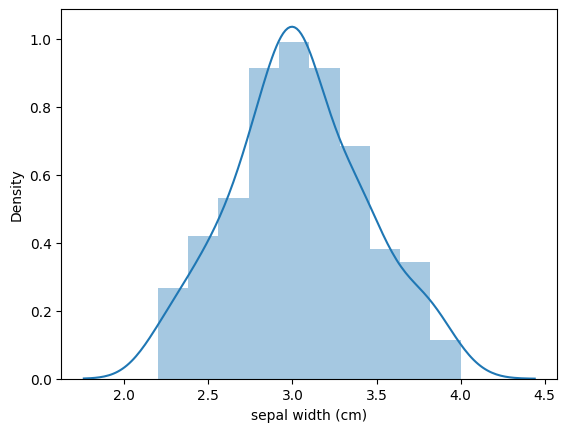

In [ ]:
sns.distplot(df1["sepal width (cm)"])

C:\Users\Dev\AppData\Local\Temp\ipykernel_28784\977188597.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["petal length (cm)"])


<Axes: xlabel='petal length (cm)', ylabel='Density'>

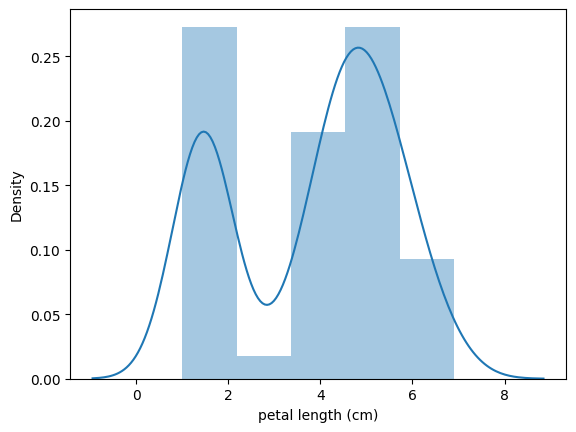

In [ ]:
sns.distplot(df1["petal length (cm)"])

C:\Users\Dev\AppData\Local\Temp\ipykernel_28784\114947628.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1["petal width (cm)"])


<Axes: xlabel='petal width (cm)', ylabel='Density'>

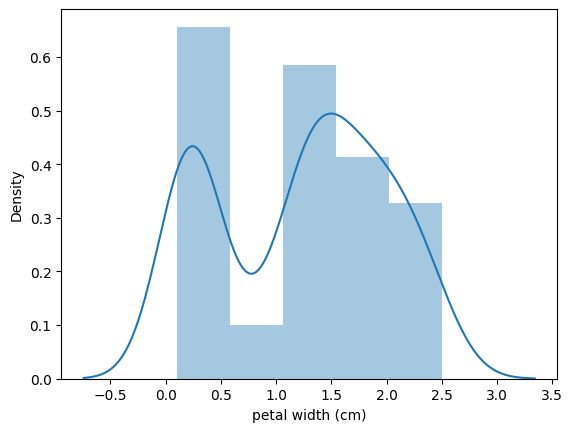

In [ ]:
sns.distplot(df1["petal width (cm)"])

In [ ]:
x = df1.drop(columns = ["label"])
y = df1["label"]

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2, random_state=7)

In [ ]:
normalizer = MinMaxScaler()
xtrain_normalized = normalizer.fit_transform(xtrain)

In [ ]:
dic_features_normalized = {
    "sepal length (cm)" : 0,
    "sepal width (cm)" : 0,
    "petal length (cm)" : 0,
    "petal width (cm)" : 0
}
sepal_length = []
sepal_width = []
petal_length = []
petal_width = []

for i in range(len(xtrain_normalized)):
    for j in range(len(xtrain_normalized[i])):
        if j == 0:
            sepal_length.append(xtrain_normalized[i][j])
        elif j == 1:
            sepal_width.append(xtrain_normalized[i][j])
        elif j == 2:
            petal_length.append(xtrain_normalized[i][j])
        else:
            petal_width.append(xtrain_normalized[i][j])

dic_features_normalized["sepal length (cm)"] = sepal_length
dic_features_normalized["sepal width (cm)"] = sepal_width
dic_features_normalized["petal length (cm)"] = petal_length
dic_features_normalized["petal width (cm)"] = petal_width

df_feat_normalized = pd.DataFrame(dic_features_normalized)
df_feat_normalized

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.472222,0.666667,0.593220,0.625000
1,0.111111,0.555556,0.101695,0.041667
2,0.583333,0.500000,0.762712,0.708333
3,0.500000,0.444444,0.661017,0.708333
4,0.611111,0.444444,0.813559,0.875000
...,...,...,...,...
111,0.138889,0.666667,0.152542,0.041667
112,0.388889,0.388889,0.542373,0.500000
113,0.833333,0.388889,0.898305,0.708333
114,0.500000,0.333333,0.508475,0.500000


C:\Users\Dev\AppData\Local\Temp\ipykernel_28784\4194311239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_feat_normalized["sepal length (cm)"])


<Axes: xlabel='sepal length (cm)', ylabel='Density'>

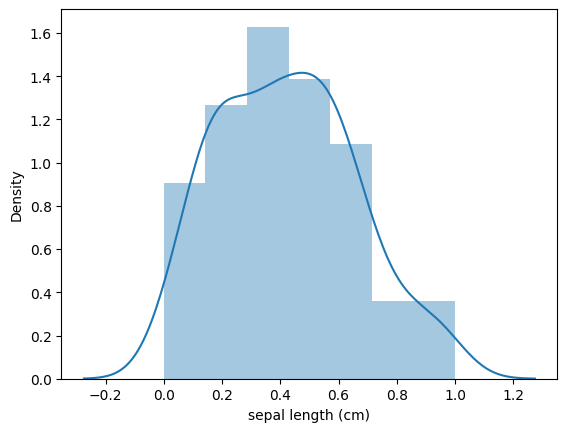

In [ ]:
sns.distplot(df_feat_normalized["sepal length (cm)"])

In [ ]:
model1 = LogisticRegression()
model1.fit(xtrain_normalized, ytrain)

LogisticRegression()

In [ ]:
xtest_normalized = normalizer.transform(xtest)

In [ ]:
ypredict1 = model1.predict(xtest_normalized)

In [ ]:
confusion_matrix(ytest, ypredict1)

array([[ 8,  0,  0],
       [ 0,  6,  3],
       [ 0,  2, 11]], dtype=int64)

In [ ]:
print(classification_report(ytest, ypredict1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.75      0.67      0.71         9
           2       0.79      0.85      0.81        13

    accuracy                           0.83        30
   macro avg       0.85      0.84      0.84        30
weighted avg       0.83      0.83      0.83        30



In [ ]:
standardizer = StandardScaler()
xtrain_standardized = standardizer.fit_transform(xtrain)

In [ ]:
model2 = LogisticRegression()
model2.fit(xtrain_standardized, ytrain)

LogisticRegression()

In [ ]:
xtest_standardized = standardizer.transform(xtest)

In [ ]:
ypredict2 = model2.predict(xtest_standardized)

In [ ]:
confusion_matrix(ytest, ypredict2)

array([[ 8,  0,  0],
       [ 0,  8,  1],
       [ 0,  1, 12]], dtype=int64)

In [ ]:
print(classification_report(ytest, ypredict2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.89      0.89      0.89         9
           2       0.92      0.92      0.92        13

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30

